In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [12]:
df = pd.read_csv(r"..\data\2slit\PMT_data\dark_rate_pmt.csv")
df1 = pd.read_csv(r"..\data\2slit\PMT_data\light_rate_pmt.csv")

In [27]:
df.voltage[5:]

5     600.8
6     619.6
7     639.8
8     662.2
9     682.8
10    700.3
11    720.8
12    741.9
13    760.2
14    780.5
15    801.5
Name: voltage, dtype: float64

In [26]:
df1

,voltage,count_rate
0,600.3,0.333
1,620.5,0.833
2,640.3,3.400
3,661.3,18.600
4,679.4,50.033
5,700.3,100.067
6,720.7,153.533
7,740.2,199.200
8,759.4,237.600
9,780.1,263.500


In [37]:
countrate_diff = []
for i in range(len(df1.count_rate)):
    countrate_diff.append( df1.count_rate.to_list()[i]  / df.count_rate.to_list()[5:][i])

In [38]:
countrate_diff

[1.11,
 1.46140350877193,
 2.913453299057412,
 5.693871740947204,
 6.949027777777777,
 9.50006170905604,
 11.486230707654094,
 7.632183908045977,
 7.156626506024096,
 5.939139038963908,
 5.287634462892005]

In [43]:
np.argmax(countrate_diff)

6

In [45]:
df1["voltage"][6]

720.7

In [44]:
countrate_diff[6]

11.486230707654094

(0.1, 1000)

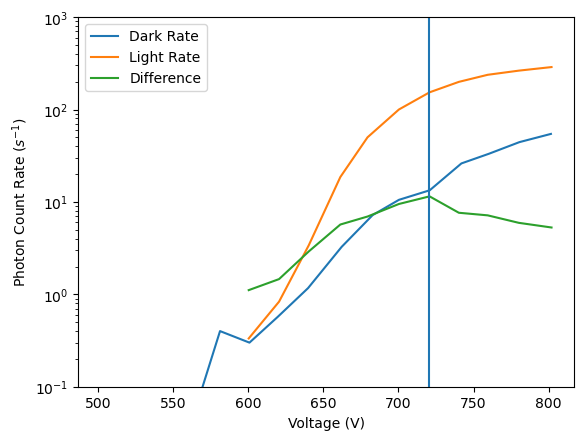

In [ ]:
fig, ax = plt.subplots()

ax.semilogy(df["voltage"],df["count_rate"],label="Dark Rate")
ax.semilogy(df1["voltage"],df1["count_rate"],label="Light Rate")
ax.semilogy(df1["voltage"],countrate_diff,label = "Difference")

ax.hlines(countrate_diff)

ax.legend()
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Photon Count Rate ($s^{-1}$)")
ax.vlines(720,0.001,10000)
ax.set_ylim(0.1,1000)

In [52]:
bulb = pd.read_csv(r"..\data\2slit\PMT_data\bulb_single_photon.csv")

<ErrorbarContainer object of 3 artists>

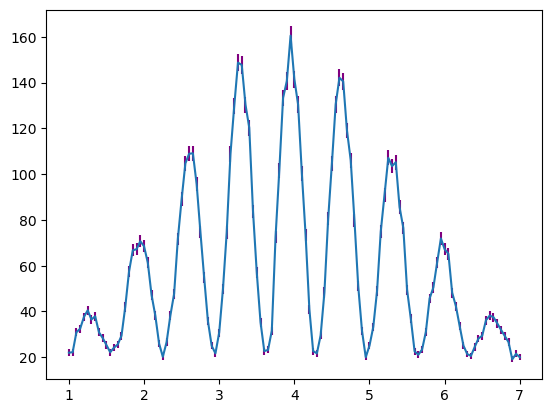

In [55]:
fig, ax = plt.subplots()

ax.errorbar(bulb.slit_pos,bulb.count_rate_1s,bulb.error_1s,ecolor="purple")